In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Extra\WGI_master_panel_final.xlsx")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Set panel index directly
df = df.set_index(['country', 'year'])

# Sort index (important for panel models)
df = df.sort_index()

print(df.head())

                  control of corruption  rule of law  \
country     year                                       
afghanistan 2004                    0.0        0.075   
            2005                    0.0        0.075   
            2006                    0.0        0.025   
            2007                    NaN          NaN   
            2008                    NaN          NaN   

                  government effectiveness  political stability  \
country     year                                                  
afghanistan 2004                      0.25               0.1875   
            2005                      0.25               0.0625   
            2006                      0.00               0.0625   
            2007                       NaN                  NaN   
            2008                       NaN                  NaN   

                  voice and accountability  regulatory quality  attacks  
country     year                                               

In [3]:
# Log transform (must for terrorism data)
df['log_attacks'] = np.log1p(df['attacks'])

# Lag variable (within each country)
df['lag_attacks'] = df.groupby(level=0)['log_attacks'].shift(1)

# Drop NA from lag
df = df.dropna()
df.head()

control of corruption  rule of law  \
country     year                                       
afghanistan 2005                    0.0        0.075   
            2006                    0.0        0.025   
            2009                    0.0        0.075   
            2010                    0.0        0.075   
            2011                    0.0        0.075   

                  government effectiveness  political stability  \
country     year                                                  
afghanistan 2005                      0.25               0.0625   
            2006                      0.00               0.0625   
            2009                      0.00               0.1250   
            2010                      0.00               0.1250   
            2011                      0.00               0.1250   

                  voice and accountability  regulatory quality  attacks  \
country     year                                                          
afghanistan 2005                  0.000000            0.107143    155.0   
            2006                  0.102000            0.107143    283.0   
            2009                  0.100667            0.107143    503.0   
            2010                  0.082667            0.107143    542.0   
            2011                  0.082667            0.107143    421.0   

                  log_attacks  lag_attacks  
country     year                            
afghanistan 2005     5.049856     4.488636  
            2006     5.648974     5.049856  
            2009     6.222576     6.028279  
            2010     6.297109     6.222576  
            2011     6.045005     6.297109

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [6]:
#(A) Normality Test (Shapiro / Jarque-Bera)

variables = ['log_attacks', 'rule of law', 'control of corruption',
             'voice and accountability', 'regulatory quality',
             'government effectiveness', 'political stability']

for var in variables:
    stat, p = stats.shapiro(df[var].dropna())
    print(f"{var}: Shapiro p-value = {p}")

log_attacks: Shapiro p-value = 2.2201791832085616e-52
rule of law: Shapiro p-value = 6.496106520161128e-27
control of corruption: Shapiro p-value = 2.704498926764265e-37
voice and accountability: Shapiro p-value = 4.817424382111462e-22
regulatory quality: Shapiro p-value = 4.796463884365639e-21
government effectiveness: Shapiro p-value = 9.583444644639285e-41
political stability: Shapiro p-value = 2.185443057951706e-19


In [8]:
#(B) Correlation Significance (Pearson Test)

for var in variables[1:]:
    corr, p = stats.pearsonr(df['log_attacks'], df[var])
    print(f"log_attacks vs {var}: Corr={corr:.3f}, p={p:.5f}")

log_attacks vs rule of law: Corr=-0.169, p=0.00000
log_attacks vs control of corruption: Corr=-0.164, p=0.00000
log_attacks vs voice and accountability: Corr=-0.144, p=0.00000
log_attacks vs regulatory quality: Corr=-0.143, p=0.00000
log_attacks vs government effectiveness: Corr=-0.051, p=0.00982
log_attacks vs political stability: Corr=-0.340, p=0.00000


       control of corruption  rule of law  government effectiveness  \
count            2600.000000  2600.000000               2600.000000   
mean                0.329712     0.480510                  0.353173   
std                 0.269742     0.241866                  0.285928   
min                 0.000000     0.025000                  0.000000   
25%                 0.125000     0.300000                  0.250000   
50%                 0.250000     0.425000                  0.250000   
75%                 0.500000     0.650000                  0.500000   
max                 1.000000     1.000000                  1.000000   

       political stability  voice and accountability  regulatory quality  \
count          2600.000000               2600.000000         2600.000000   
mean              0.558882                  0.467540            0.496484   
std               0.244107                  0.260718            0.224479   
min               0.000000                  0.000000    

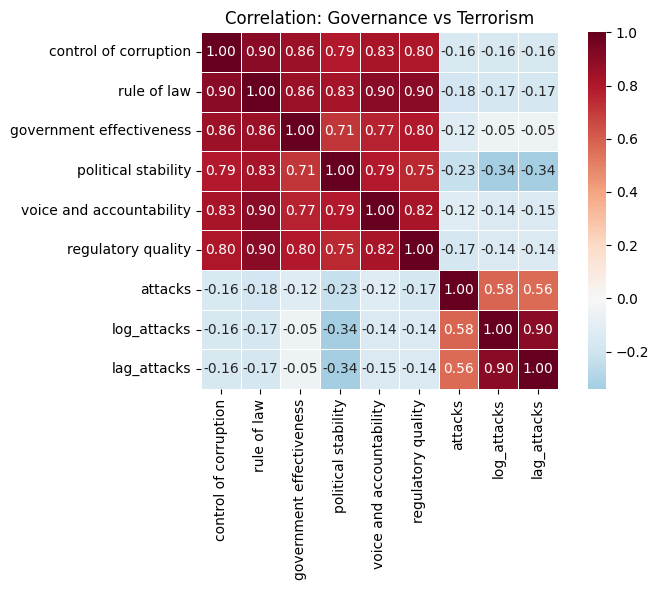

In [9]:
print(df.describe())

# Correlation heatmap
cols = [
    "control of corruption",
    "rule of law",
    "government effectiveness",
    "political stability",
    "voice and accountability",
    "regulatory quality",
    "attacks",
    "log_attacks",
    "lag_attacks"
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation: Governance vs Terrorism")
plt.tight_layout()
plt.show()

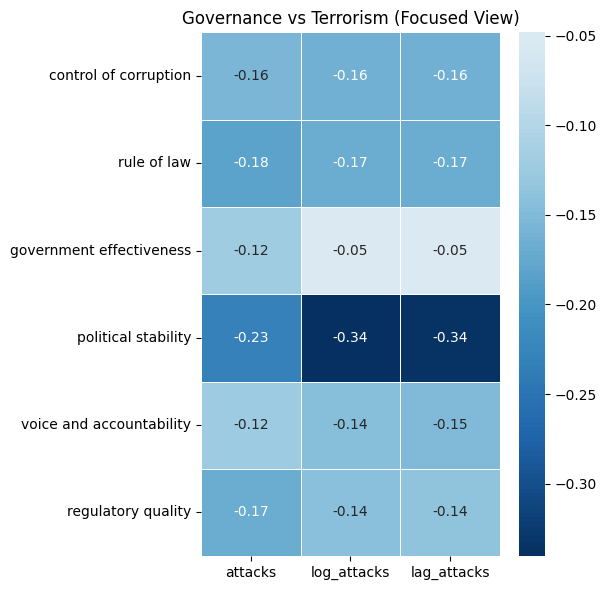

In [10]:
# Separate governance vs terrorism variables
gov_cols = [
    'control of corruption',
    'rule of law',
    'government effectiveness',
    'political stability',
    'voice and accountability',
    'regulatory quality'
]

target_cols = ['attacks','log_attacks', 'lag_attacks']

# Compute cross-correlation only
corr_matrix = df[gov_cols + target_cols].corr().loc[gov_cols, target_cols]

plt.figure(figsize=(6,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Governance vs Terrorism (Focused View)")
plt.tight_layout()
plt.show()

In [11]:
X = df[[
    "control of corruption",
    "rule of law",
    "government effectiveness",
    "political stability",
    "voice and accountability",
    "regulatory quality"
]]

X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

                   Variable        VIF
0                     const   9.690027
1     control of corruption   6.566870
2               rule of law  14.154400
3  government effectiveness   4.636356
4       political stability   3.452504
5  voice and accountability   5.391366
6        regulatory quality   5.286918


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gov_vars = df[['control of corruption','rule of law','government effectiveness',
               'political stability','voice and accountability','regulatory quality']]

scaler = StandardScaler()
gov_scaled = scaler.fit_transform(gov_vars)

pca = PCA(n_components=1)
df['governance_index'] = pca.fit_transform(gov_scaled)
print(pca.explained_variance_ratio_)

loadings = pd.DataFrame(pca.components_.T, 
                        columns=['PC1'], 
                        index=gov_vars.columns)
print(loadings)

[0.85158379]
                               PC1
control of corruption     0.414154
rule of law               0.431310
government effectiveness  0.399654
political stability       0.388951
voice and accountability  0.408568
regulatory quality        0.405604


In [13]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_[0])

loadings['abs_loading'] = loadings['PC1'].abs()
loadings = loadings.sort_values(by='abs_loading', ascending=False)
print(loadings)

Explained Variance Ratio: 0.8515837891449871
                               PC1  abs_loading
rule of law               0.431310     0.431310
control of corruption     0.414154     0.414154
voice and accountability  0.408568     0.408568
regulatory quality        0.405604     0.405604
government effectiveness  0.399654     0.399654
political stability       0.388951     0.388951


Principal Component Analysis (PCA) was applied to six World Governance Indicators to construct a composite governance index. The first principal component explained 85.16% of the total variance, indicating a strong common underlying factor. All indicators exhibited positive and nearly equal loadings (ranging from 0.389 to 0.431), suggesting that each dimension contributes uniformly to governance quality. Therefore, the first principal component was retained as a robust measure of overall governance.

In [15]:
import numpy as np

df=df.reset_index()

# sort before lagging
df = df.sort_values(['country', 'year'])

# create lags (panel-wise)
df['log_attack_lag1'] = df.groupby('country')['log_attacks'].shift(1)
df['log_attack_lag2'] = df.groupby('country')['log_attacks'].shift(2)

# drop missing values from lagging
df = df.dropna()

df = df.set_index(['country', 'year'])
df.head()

index  control of corruption  rule of law  \
country     year                                              
afghanistan 2009      2                    0.0        0.075   
            2010      3                    0.0        0.075   
            2011      4                    0.0        0.075   
            2012      5                    0.0        0.075   
            2013      6                    0.0        0.075   

                  government effectiveness  political stability  \
country     year                                                  
afghanistan 2009                       0.0                0.125   
            2010                       0.0                0.125   
            2011                       0.0                0.125   
            2012                       0.0                0.125   
            2013                       0.0                0.125   

                  voice and accountability  regulatory quality  attacks  \
country     year                                                          
afghanistan 2009                  0.100667            0.107143    503.0   
            2010                  0.082667            0.107143    542.0   
            2011                  0.082667            0.107143    421.0   
            2012                  0.082667            0.107143   1469.0   
            2013                  0.082667            0.107143   1443.0   

                  log_attacks  lag_attacks  governance_index  log_attack_lag1  \
country     year                                                                
afghanistan 2009     6.222576     6.028279         -3.693459         5.648974   
            2010     6.297109     6.222576         -3.721672         6.222576   
            2011     6.045005     6.297109         -3.721672         6.297109   
            2012     7.293018     6.045005         -3.721672         6.045005   
            2013     7.275172     7.293018         -3.721672         7.293018   

                  log_attack_lag2  
country     year                   
afghanistan 2009         5.049856  
            2010         5.648974  
            2011         6.222576  
            2012         6.297109  
            2013         6.045005

In [17]:
#(C) Mean Difference Test (Optional – High vs Low Governance)

df['gov_dummy'] = np.where(df['governance_index'] > df['governance_index'].median(), 1, 0)

group1 = df[df['gov_dummy'] == 1]['log_attacks']
group0 = df[df['gov_dummy'] == 0]['log_attacks']

t_stat, p_val = stats.ttest_ind(group1, group0)
print("T-test p-value:", p_val)

T-test p-value: 3.204275432013622e-21


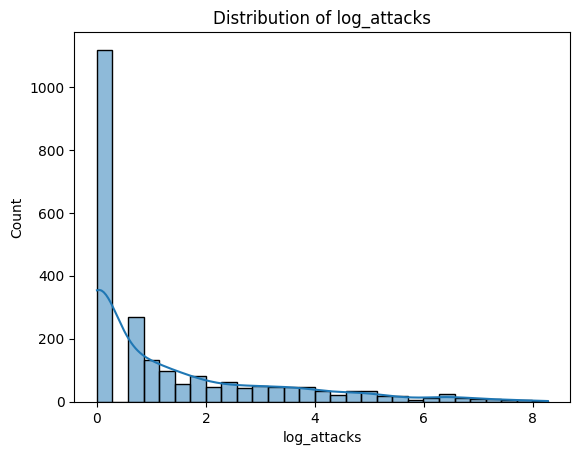

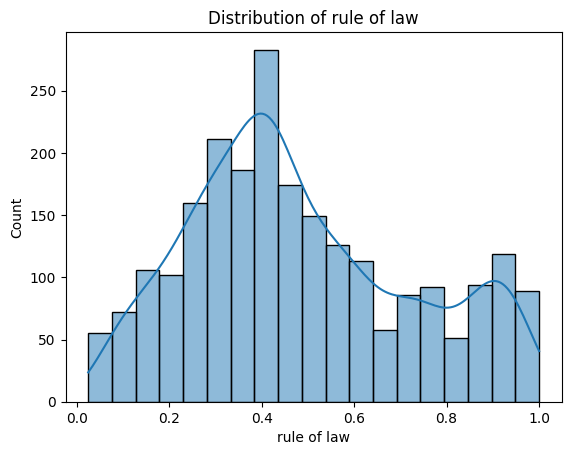

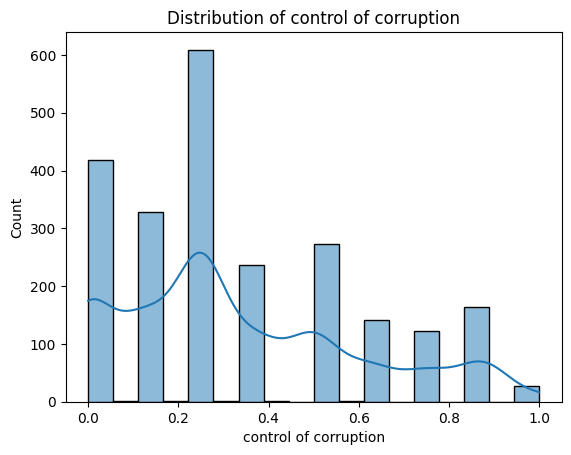

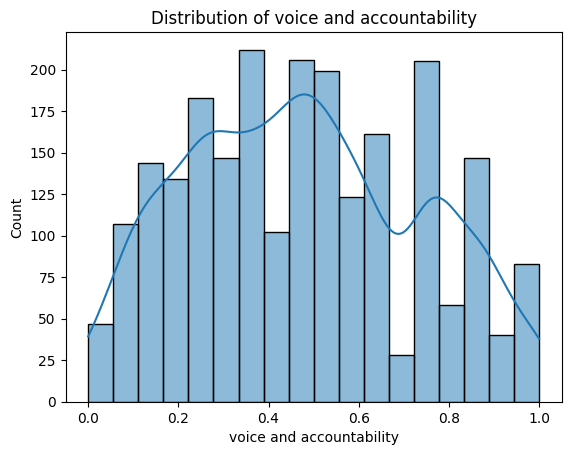

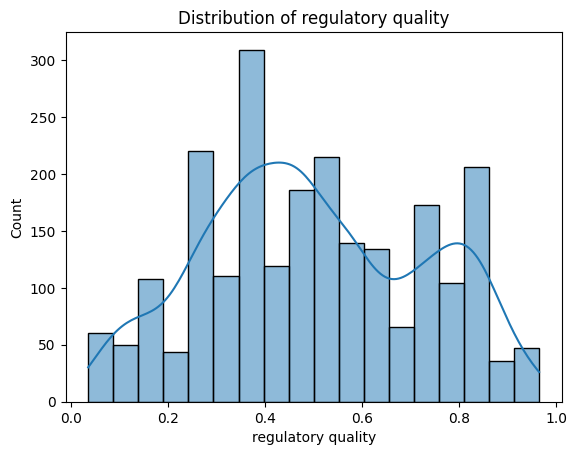

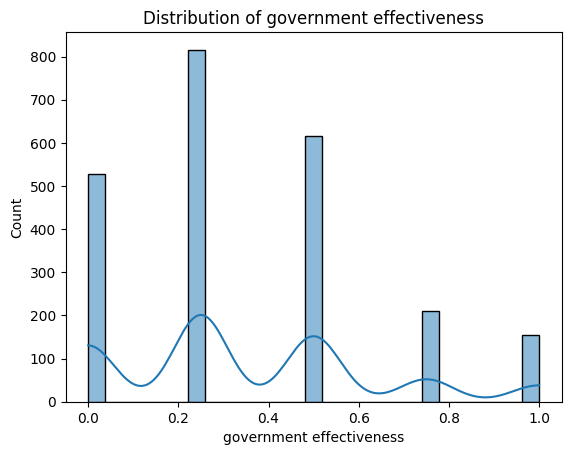

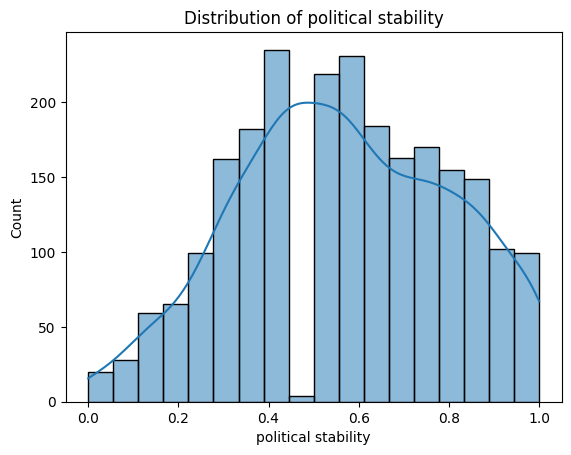

In [18]:
#3. Visualizations for Inferential Analysis

#Distribution PLots
for var in variables:
    plt.figure()
    sns.histplot(df[var], kde=True)
    plt.title(f"Distribution of {var}")
    plt.show()

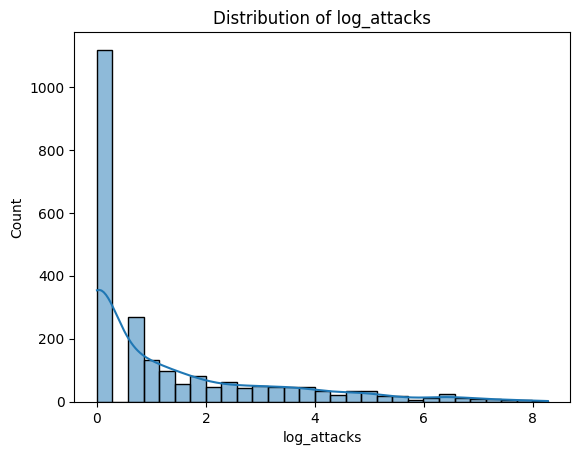

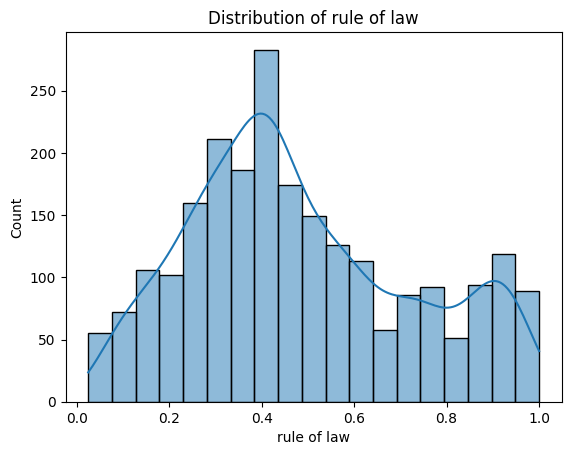

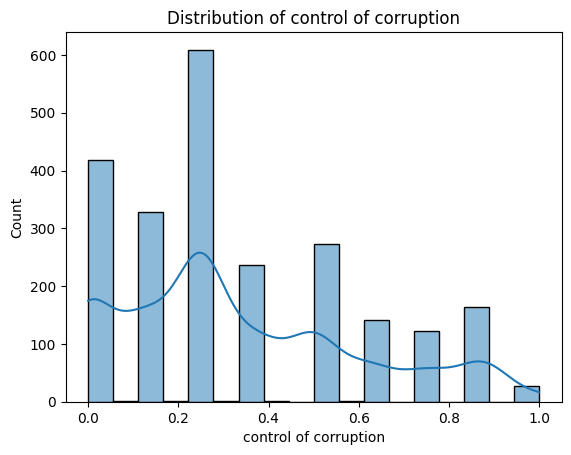

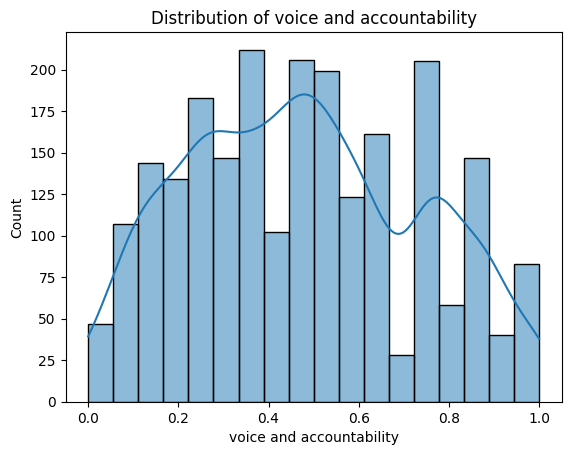

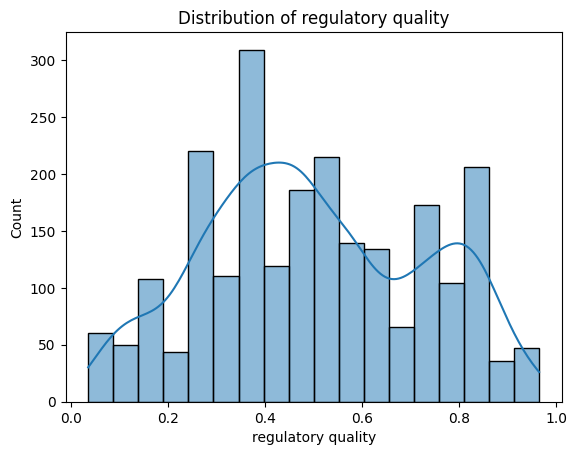

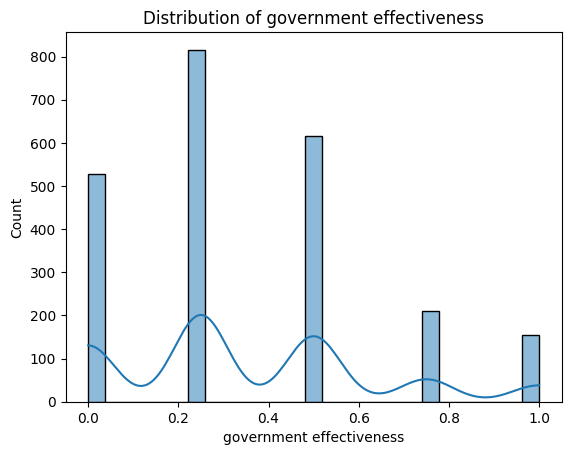

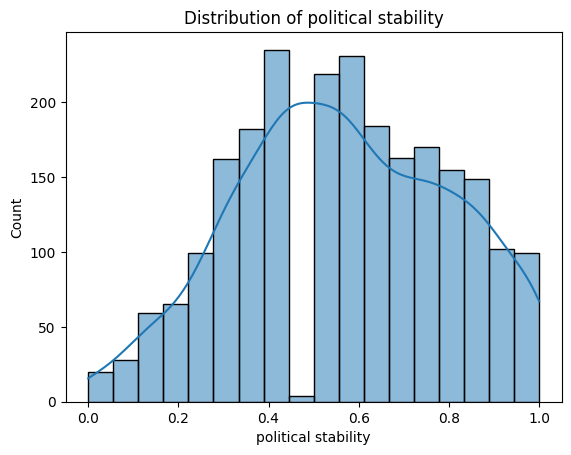

In [19]:
#Boxplots
for var in variables:
    plt.figure()
    sns.histplot(df[var], kde=True)
    plt.title(f"Distribution of {var}")
    plt.show()

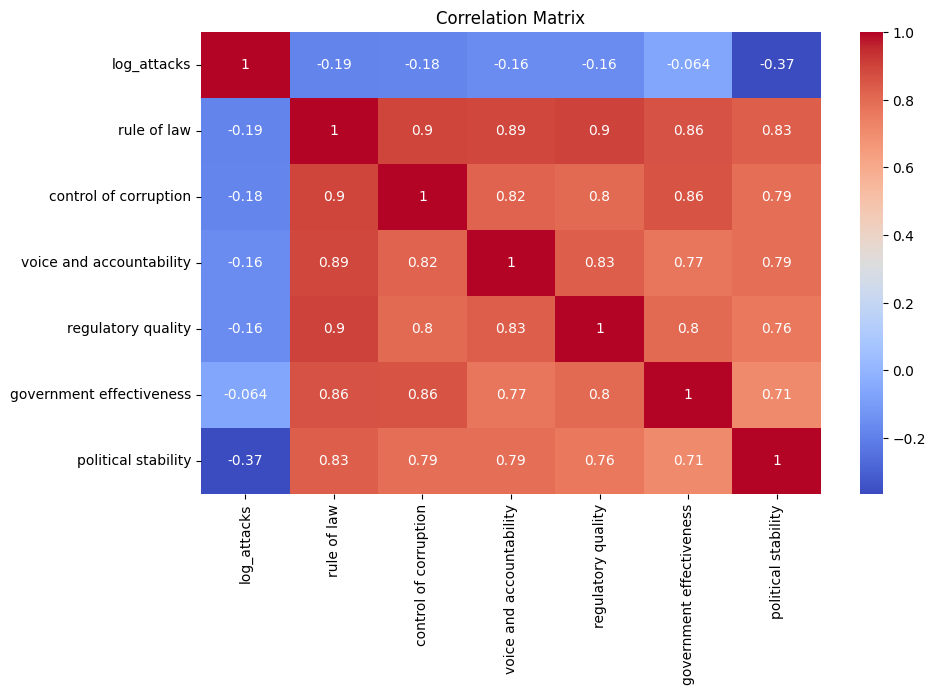

In [20]:
#correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[variables].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

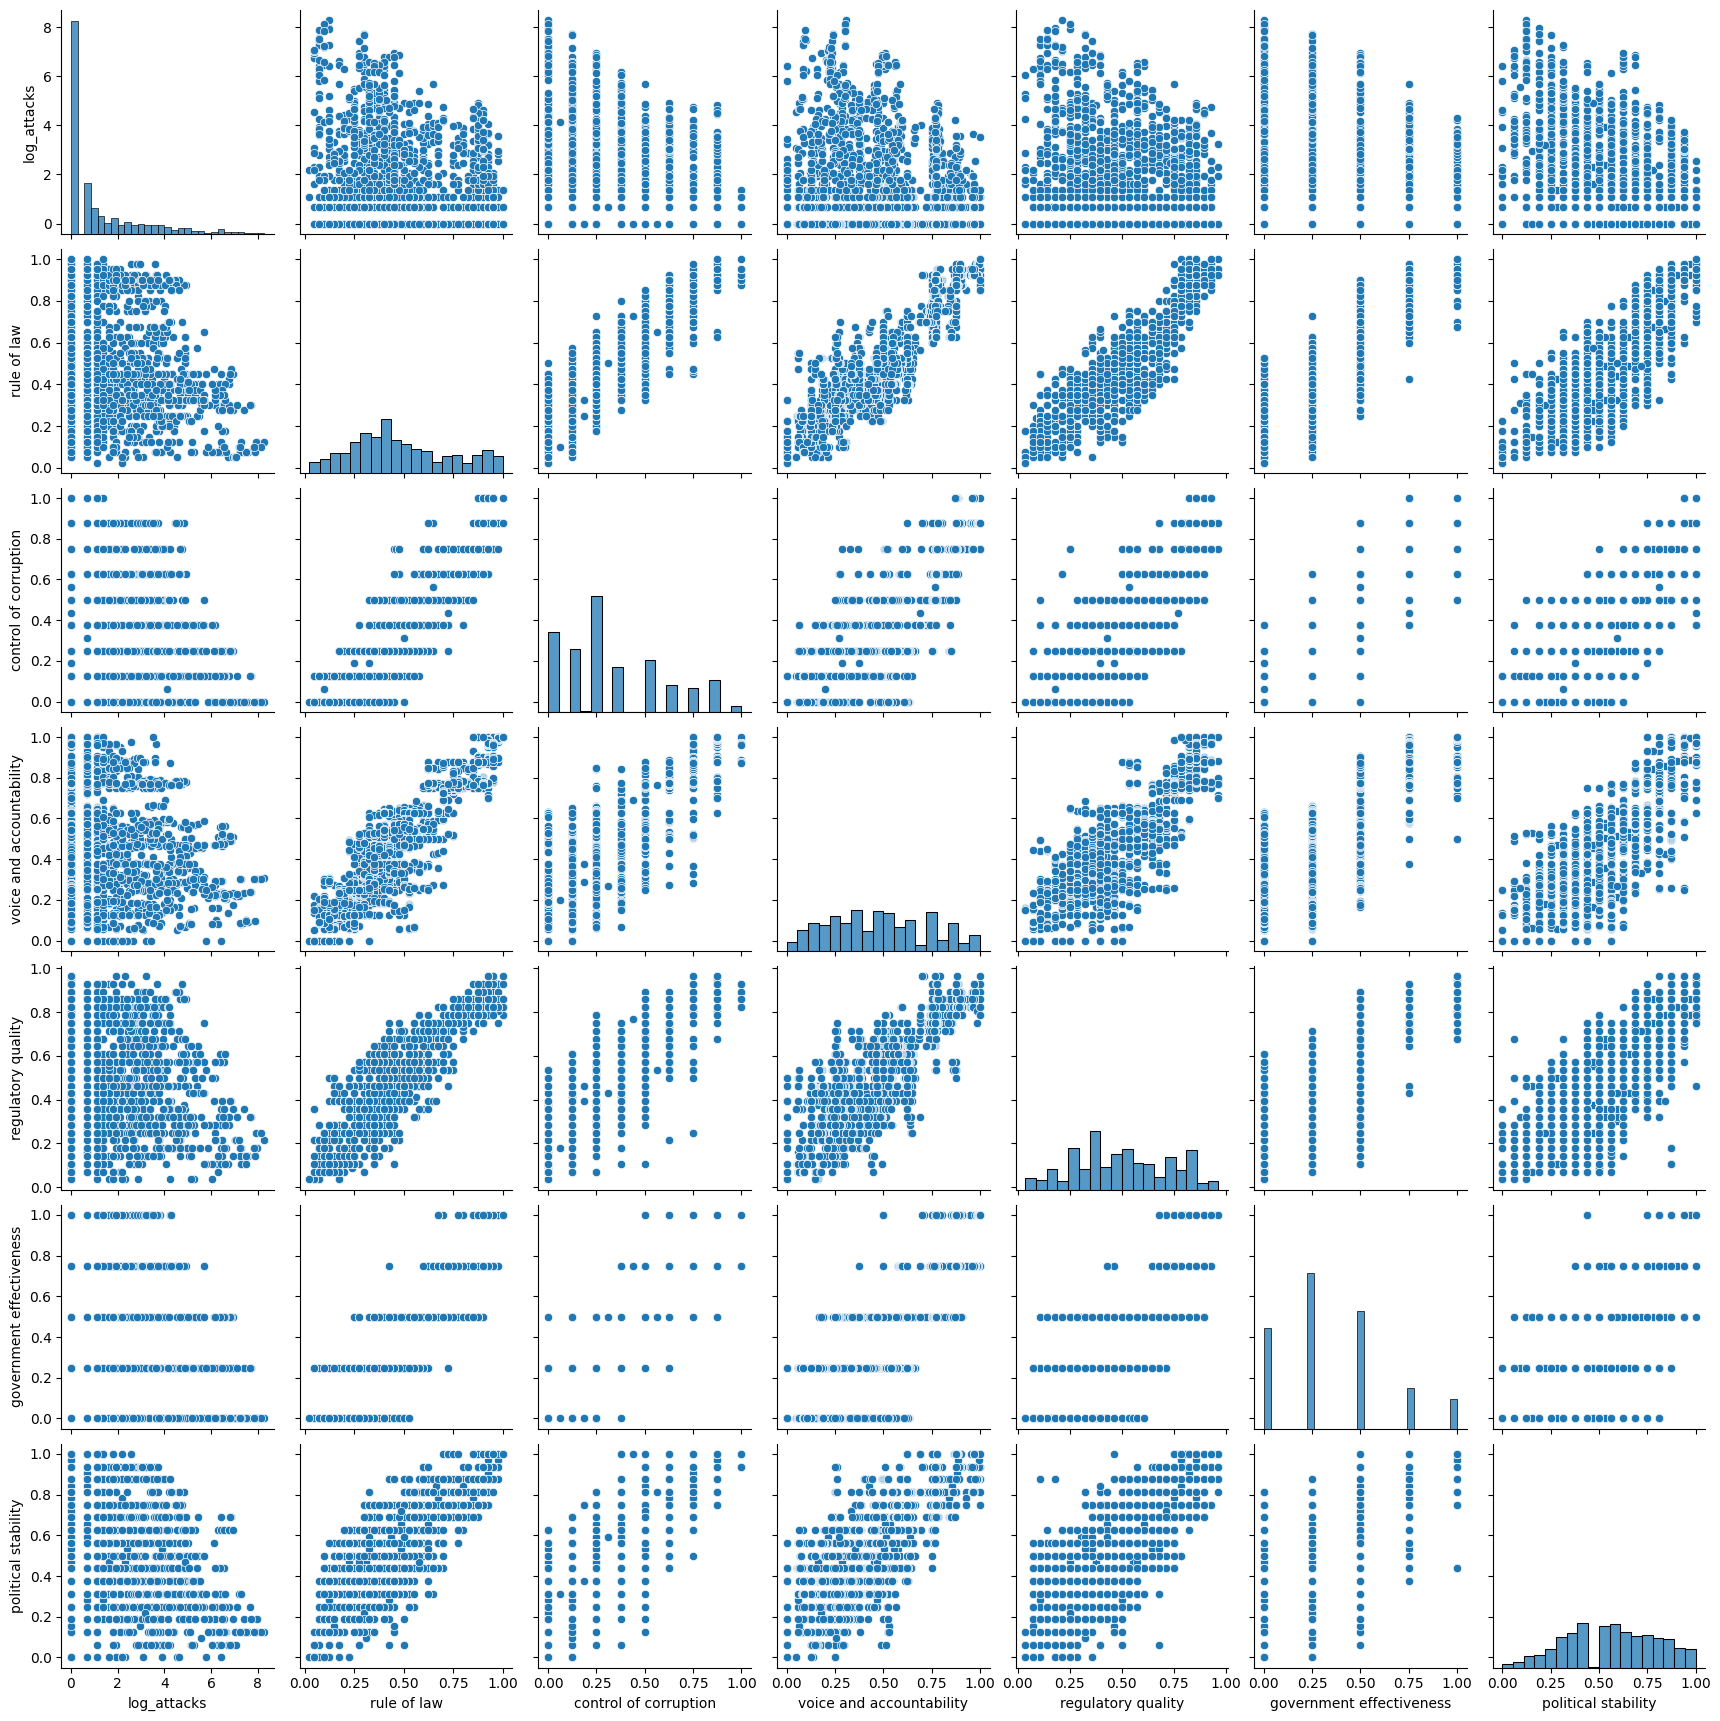

In [21]:
#Pairplots
sns.pairplot(df[variables])
plt.show()

MODEL 1: All 6 Variables + Dynamic Lags

In [23]:
#4. Regression Model (Simple OLS for Visualization Purpose)

X = df[['rule of law', 'control of corruption',
        'voice and accountability', 'regulatory quality',
        'government effectiveness', 'political stability']]

X = sm.add_constant(X)
y = df['log_attacks']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_attacks   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     109.7
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          4.72e-122
Time:                        13:47:34   Log-Likelihood:                -4345.8
No. Observations:                2326   AIC:                             8706.
Df Residuals:                    2319   BIC:                             8746.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [24]:
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

#Define Variables
X_6 = df[['log_attack_lag1', 'log_attack_lag2',
          'rule of law','control of corruption','voice and accountability',
          'regulatory quality','government effectiveness','political stability']]

y = df['log_attack']

#Fixed Effects (Dynamic Panel)
model_fe_6 = PanelOLS(y, X_6, entity_effects=True)
fe_results_6 = model_fe_6.fit(cov_type='clustered', cluster_entity=True)

print(fe_results_6.summary)


KeyError: 'log_attack'

1. Moderate Within-Country Explanatory Power
The model explains 37.6% of within-country variation (Within R² = 0.3761), indicating a moderate ability to capture temporal dynamics in terrorism.
Lower Between R² (0.7832) compared to Random Effects suggests reduced emphasis on cross-country variation, which is expected under Fixed Effects.

2. Strong Persistence in Terrorism Dynamics
log_attack_lag1 (0.4726) and log_attack_lag2 (0.1362) are positive and highly significant (p < 0.001).
Confirms path dependency, with past attacks influencing current levels, though with smaller magnitudes than Random Effects—indicating more reliable within-country estimates.

3. Limited Significance of Governance Indicators
Most governance variables (rule of law, corruption, voice, regulatory quality, government effectiveness) are statistically insignificant.
Suggests that short-term within-country changes in governance do not significantly affect terrorism in this specification.

4. Political Stability as a Key Determinant
Political stability (-1.4671, p < 0.001) is negative and highly significant.
Indicates that improvements in political stability substantially reduce terrorism, making it the only robust governance-related predictor in this model.

5. Model Validity and Econometric Implications
F-test for poolability (p < 0.001) confirms the presence of significant country-specific effects, justifying the use of Fixed Effects.
Use of clustered standard errors improves robustness.
However, potential issues remain:
Multicollinearity among governance variables
Endogeneity due to lagged dependent variables
Need for dynamic panel methods (e.g., GMM) for more consistent estimation.

In [ ]:
#Random Effects
model_re_6 = RandomEffects(y, X_6)
re_results_6 = model_re_6.fit()

print(re_results_6.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             log_attack   R-squared:                        0.9080
Estimator:              RandomEffects   R-squared (Between):              0.9934
No. Observations:                1778   R-squared (Within):               0.2768
Date:                Fri, Mar 20 2026   R-squared (Overall):              0.9080
Time:                        19:17:30   Log-likelihood                   -1910.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2182.9
Entities:                         137   P-value                           0.0000
Avg Obs:                       12.978   Distribution:                  F(8,1770)
Min Obs:                       5.0000                                           
Max Obs:                       15.000   F-statistic (robust):             2182.9
                            

1. Strong Model Fit with Cross-Sectional Dominance
The model explains a substantial proportion of variation (R² = 0.908).
Extremely high Between R² (0.9934) vs low Within R² (0.2768) indicates the model primarily captures cross-country differences rather than within-country temporal changes.

2. High Persistence in Terrorism Dynamics
Both lag variables are positive and highly significant.
This confirms that terrorism is strongly path-dependent, with past incidents significantly increasing current incidents.

3. Limited Role of Governance Indicators
Among all governance variables, only control of corruption is statistically significant and negatively related to terrorism.
Other indicators show no significant direct effect, suggesting weak immediate influence.

4. Possible Econometric Issues
Insignificance of governance variables may stem from:
Multicollinearity among WGI indicators
Endogeneity due to lagged dependent variables
The Random Effects assumption (no correlation between effects and regressors) may be questionable in this context.

5. Policy and Modeling Implications
Anti-corruption measures emerge as a key policy tool to reduce terrorism.
Results suggest the need for dynamic panel models and alternative specifications to better capture governance effects.

MODEL 2: PCA Governance Index + Dynamic Lags

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gov_vars = df[['rule of law','control of corruption','voice and accountability',
               'regulatory quality','government effectiveness','political stability']]

scaler = StandardScaler()
gov_scaled = scaler.fit_transform(gov_vars)

pca = PCA(n_components=1)
df['governance_index'] = pca.fit_transform(gov_scaled)

#Define Variables
X_pca = df[['log_attack_lag1', 'log_attack_lag2', 'governance_index']]
y = df['log_attack']

#Fixed Effects (Dynamic)
model_fe_pca = PanelOLS(y, X_pca, entity_effects=True)
fe_results_pca = model_fe_pca.fit(cov_type='clustered', cluster_entity=True)

print(fe_results_pca.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             log_attack   R-squared:                        0.3628
Estimator:                   PanelOLS   R-squared (Between):              0.8621
No. Observations:                1778   R-squared (Within):               0.3628
Date:                Fri, Mar 20 2026   R-squared (Overall):              0.7990
Time:                        19:21:42   Log-likelihood                   -1746.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      310.86
Entities:                         137   P-value                           0.0000
Avg Obs:                       12.978   Distribution:                  F(3,1638)
Min Obs:                       5.0000                                           
Max Obs:                       15.000   F-statistic (robust):             124.84
                            

1. Moderate Within-Country Explanatory Power
The model explains 36.3% of within-country variation (Within R² = 0.3628), indicating a moderate fit for temporal dynamics.
Higher Between R² (0.8621) and Overall R² (0.7990) suggest the model still captures substantial cross-sectional variation, but less strongly than Random Effects.

2. Strong and Significant Persistence in Terrorism
log_attack_lag1 (0.4912) and log_attack_lag2 (0.1505) are positive and highly significant.
Confirms dynamic persistence, though coefficients are smaller than in Random Effects, indicating a more realistic within-country effect after controlling for fixed heterogeneity.

3. Governance Index Shows No Significant Effect
Governance_index (-0.1000, p = 0.2106) is statistically insignificant.
Suggests that within-country changes in governance do not have a strong immediate impact on terrorism in this specification.

4. Fixed Effects Are Necessary
F-test for poolability (p < 0.001) strongly rejects pooled OLS.
Indicates significant unobserved country-specific heterogeneity, justifying the use of Fixed Effects over pooled models.

5. Improved Econometric Reliability but Remaining Challenges
Use of clustered standard errors improves inference robustness.
However:
Possible endogeneity due to lagged dependent variables persists
Governance effects may be lagged, nonlinear, or indirect
Suggests need for dynamic panel methods (e.g., Arellano–Bond) for more consistent estimates.

In [ ]:
#Random Effects
model_re_pca = RandomEffects(y, X_pca)
re_results_pca = model_re_pca.fit()

print(re_results_pca.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             log_attack   R-squared:                        0.9064
Estimator:              RandomEffects   R-squared (Between):              0.9938
No. Observations:                1778   R-squared (Within):               0.2616
Date:                Fri, Mar 20 2026   R-squared (Overall):              0.9064
Time:                        19:21:53   Log-likelihood                   -1926.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      5727.5
Entities:                         137   P-value                           0.0000
Avg Obs:                       12.978   Distribution:                  F(3,1775)
Min Obs:                       5.0000                                           
Max Obs:                       15.000   F-statistic (robust):             5727.5
                            

1. Excellent Overall Fit Driven by Cross-Sectional Variation
The model exhibits very high explanatory power (R² = 0.9064).
The Between R² (0.9938) is high, indicating the model captures cross-country differences almost perfectly, while Within R² (0.2616) remains low, showing weak performance in explaining temporal changes within countries.

2. Strong Evidence of Terrorism Persistence
log_attack_lag1 (0.7029) and log_attack_lag2 (0.2856) are positive and highly significant (p < 0.001).
This confirms high persistence and inertia in terrorism, where past incidents strongly influence present outcomes, even across multiple time periods.

3. Governance Index Has No Significant Impact
Governance_index (-0.0049, p = 0.5220) is statistically insignificant and economically negligible.
Suggests that aggregate governance quality does not have a direct measurable effect on terrorism in the Random Effects framework.

4. Dominance of Lag Effects Over Institutional Variables
The large magnitude and significance of lag variables indicate that historical dependence overshadows institutional effects.
This may imply:
Governance impacts are indirect or long-term
Or masked due to model specification and aggregation (index formation)

5. Econometric Limitations and Model Implications
Random Effects assumes no correlation between unobserved heterogeneity and regressors, which may be unrealistic in governance-terrorism settings.
Low within explanatory power and insignificant governance effect suggest:
Need for Fixed Effects or dynamic panel models (Arellano–Bond)
Potential issues of endogeneity and omitted variable bias

In [ ]:
#(A) Actual vs Predicted Plot
df['predicted'] = model.predict(X)

plt.figure()
plt.scatter(df['log_attack'], df['predicted'])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
#(B) Residual Plot
df['residuals'] = df['log_attack'] - df['predicted']

plt.figure()
sns.scatterplot(x=df['predicted'], y=df['residuals'])
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

In [ ]:
#(C) Residual Distribution
plt.figure()
sns.histplot(df['residuals'], kde=True)
plt.title("Residual Distribution")
plt.show()